# Visualize Raw ETKDG Conformers

This notebook reads a generated conformer SDF shard plus its `manifest.tsv`, summarizes the generation run, rebuilds one RDKit multi-conformer molecule, aligns conformers using RDKit's conformer alignment API, and plots RMSD diagnostics.

If needed, install visualization dependencies in the `chembl3d` environment:

```bash
conda activate chembl3d
pip install py3Dmol notebook ipywidgets matplotlib pandas
```

In [50]:
from pathlib import Path
import csv
from collections import Counter

from rdkit import Chem
from rdkit.Chem import AllChem, Descriptors, rdMolAlign
import py3Dmol

try:
    import matplotlib.pyplot as plt
except ImportError:
    plt = None

try:
    import pandas as pd
except ImportError:
    pd = None

try:
    from ipywidgets import interact, IntSlider, Dropdown
except ImportError:
    interact = None
    IntSlider = None
    Dropdown = None

## Pick a generated conformer run

The dropdown scans `/mnt/weka/mbedrosian` for directories named `chembl3d_etkdg*` that contain a `manifest.tsv`. Pick a run, then execute the loading/audit cells below.

In [51]:
search_root = Path("/mnt/weka/mbedrosian")
manifest_paths = sorted(search_root.glob("chembl3d_etkdg*/manifest.tsv"))

# Fallback to the current sample path if the glob finds nothing.
default_run_dir = Path("/mnt/weka/mbedrosian/chembl3d_etkdg_updated_group019_CHEMBL3183213_0_keep20")
if not manifest_paths and (default_run_dir / "manifest.tsv").exists():
    manifest_paths = [default_run_dir / "manifest.tsv"]

run_options = [(path.parent.name, str(path.parent)) for path in manifest_paths]
assert run_options, f"No generated runs with manifest.tsv found under {search_root}"

if Dropdown is None:
    run_dir = Path(run_options[0][1])
    print("ipywidgets is not installed; using first run:", run_dir)
else:
    run_dir_picker = Dropdown(options=run_options, value=run_options[0][1], description="Run:")
    display(run_dir_picker)
    print("After changing the dropdown, rerun the next cells to reload that run.")

Dropdown(description='Run:', options=(('chembl3d_etkdg_sample_group010_first', '/mnt/weka/mbedrosian/chembl3d_…

After changing the dropdown, rerun the next cells to reload that run.


In [ ]:
if Dropdown is not None:
    run_dir = Path(run_dir_picker.value)

manifest_path = run_dir / "manifest.tsv"
assert manifest_path.exists(), manifest_path

with manifest_path.open() as handle:
    manifest_rows = list(csv.DictReader(handle, delimiter="	"))

assert manifest_rows, manifest_path
row = manifest_rows[0]
sdf_path = Path(row["sdf_path"])
pickle_path = Path(row["pickle_path"])
assert sdf_path.exists(), sdf_path

mols = [mol for mol in Chem.SDMolSupplier(str(sdf_path), removeHs=False) if mol is not None]
assert mols, sdf_path

base_mol = Chem.Mol(mols[0])
smiles_by_conf = [Chem.MolToSmiles(Chem.RemoveHs(Chem.Mol(mol)), isomericSmiles=True) for mol in mols]
unique_smiles_counts = Counter(smiles_by_conf)
smiles = smiles_by_conf[0]
heavy_atoms = sum(1 for atom in base_mol.GetAtoms() if atom.GetAtomicNum() > 1)
total_atoms = base_mol.GetNumAtoms()
rotatable_bonds = int(Descriptors.NumRotatableBonds(base_mol))

summary = {
    "mol_id": row.get("mol_id"),
    "group": row.get("group"),
    "run_dir": str(run_dir),
    "topology_smiles": smiles,
    "unique_generated_smiles": dict(unique_smiles_counts),
    "num_unique_generated_smiles": len(unique_smiles_counts),
    "heavy_atoms": heavy_atoms,
    "total_atoms": total_atoms,
    "rotatable_bonds": rotatable_bonds,
    "target_confs": int(row.get("target_confs", 0)),
    "generated_candidates": int(row.get("generated_candidates", 0)),
    "kept_confs": int(row.get("kept_confs", len(mols))),
    "clash_rejected": int(row.get("clash_rejected", 0)),
    "bond_rejected": int(row.get("bond_rejected", 0)),
    "stereo_rejected": int(row.get("stereo_rejected", 0)),
    "energy_rejected": int(row.get("energy_rejected", 0)),
    "status": row.get("status"),
    "sdf_path": str(sdf_path),
    "pickle_path": str(pickle_path),
}
summary

In [43]:
def print_generation_audit(summary):
    generated = summary["generated_candidates"]
    kept = summary["kept_confs"]
    rejected = (
        summary["clash_rejected"]
        + summary["bond_rejected"]
        + summary["stereo_rejected"]
        + summary["energy_rejected"]
    )
    unused = max(0, generated - rejected - kept)

    print(f"mol_id: {summary['mol_id']}")
    print(f"topology/generator SMILES: {summary['topology_smiles']}")
    print(f"unique SMILES across generated conformer records: {summary['num_unique_generated_smiles']}")
    for smi, count in summary["unique_generated_smiles"].items():
        print(f"  {count}x {smi}")
    print(f"atoms: {summary['total_atoms']} total, {summary['heavy_atoms']} heavy")
    print(f"rotatable_bonds: {summary['rotatable_bonds']}")
    print(f"generated_candidates: {generated}")
    print(f"kept_confs: {kept}")
    print(f"rejected_total: {rejected}")
    print(f"  clash_rejected: {summary['clash_rejected']}")
    print(f"  bond_rejected: {summary['bond_rejected']}")
    print(f"  stereo_rejected: {summary['stereo_rejected']}")
    print(f"  energy_rejected: {summary['energy_rejected']}")
    print(f"valid_but_not_selected: {unused}")
    print(f"status: {summary['status']}")

print_generation_audit(summary)

mol_id: CHEMBL3183213_0
topology/generator SMILES: O=C([O-])C(F)(F)C(F)(F)C(F)(F)C(F)(F)C(F)(F)F
unique SMILES across generated conformer records: 1
  20x O=C([O-])C(F)(F)C(F)(F)C(F)(F)C(F)(F)C(F)(F)F
atoms: 19 total, 19 heavy
rotatable_bonds: 4
generated_candidates: 100
kept_confs: 20
rejected_total: 0
  clash_rejected: 0
  bond_rejected: 0
  stereo_rejected: 0
  energy_rejected: 0
valid_but_not_selected: 80
status: ok


## Alignment method

For conformers of the **same molecule with the same atom order**, the robust visualization path is:

1. Rebuild one RDKit molecule containing all conformers.
2. Align all conformers to conformer `0` with `rdMolAlign.AlignMolConformers`.
3. Use heavy atoms for alignment by default, not a small anchor fragment.
4. Compute RMSD either after this alignment or with RDKit's symmetry-aware conformer RMSD functions.

A flexible molecule will still look spread out after correct alignment because rotatable groups occupy different positions. The key check is whether the shared scaffold/overall least-squares fit is stable, not whether every atom overlaps.

In [44]:
def heavy_atom_indices(mol):
    atoms = [atom.GetIdx() for atom in mol.GetAtoms() if atom.GetAtomicNum() > 1]
    return atoms if atoms else list(range(mol.GetNumAtoms()))


def rebuild_multiconformer_mol(records):
    """Convert one-record-per-conformer SDF records into one RDKit Mol with many conformers."""
    template = Chem.Mol(records[0])
    template.RemoveAllConformers()
    template.SetProp("_Name", summary["mol_id"] or records[0].GetProp("_Name"))

    for conf_id, record in enumerate(records):
        if record.GetNumAtoms() != template.GetNumAtoms():
            raise ValueError(f"record {conf_id} has a different atom count")
        conf = Chem.Conformer(record.GetConformer(0))
        conf.SetId(conf_id)
        template.AddConformer(conf, assignId=True)
    return template


def copy_with_all_conformers(mol):
    return Chem.Mol(mol)


def lower_triangular_to_square(values, n):
    matrix = [[0.0 for _ in range(n)] for _ in range(n)]
    cursor = 0
    for i in range(1, n):
        for j in range(i):
            matrix[i][j] = matrix[j][i] = float(values[cursor])
            cursor += 1
    return matrix


multi_mol = rebuild_multiconformer_mol(mols)
alignment_atom_ids = heavy_atom_indices(multi_mol)
aligned_multi_mol = copy_with_all_conformers(multi_mol)
rms_to_ref = []
rdMolAlign.AlignMolConformers(
    aligned_multi_mol,
    atomIds=alignment_atom_ids,
    RMSlist=rms_to_ref,
)

print(f"conformers={aligned_multi_mol.GetNumConformers()}")
print(f"alignment=rdMolAlign.AlignMolConformers")
print(f"reference_conf=0")
print(f"alignment_atoms=heavy atoms ({len(alignment_atom_ids)} atoms)")
if rms_to_ref:
    print(
        "RMSD_to_reference_A: "
        f"min={min(rms_to_ref):.3f}, "
        f"median={sorted(rms_to_ref)[len(rms_to_ref)//2]:.3f}, "
        f"max={max(rms_to_ref):.3f}"
    )

conformers=20
alignment=rdMolAlign.AlignMolConformers
reference_conf=0
alignment_atoms=heavy atoms (19 atoms)
RMSD_to_reference_A: min=1.680, median=1.906, max=2.299


In [45]:
def show_conformer(conf_idx=0, width=700, height=500):
    conf_idx = int(conf_idx)
    view = py3Dmol.view(width=width, height=height)
    view.addModel(Chem.MolToMolBlock(aligned_multi_mol, confId=conf_idx), "sdf")
    view.setStyle({"stick": {"radius": 0.16}, "sphere": {"scale": 0.24}})
    view.zoomTo()
    view.show()

    original = mols[conf_idx]
    print("mol_id:", original.GetProp("mol_id") if original.HasProp("mol_id") else summary["mol_id"])
    print("conf_id:", original.GetProp("conf_id") if original.HasProp("conf_id") else conf_idx)
    print("generation_seed:", original.GetProp("generation_seed") if original.HasProp("generation_seed") else "NA")
    if conf_idx > 0 and len(rms_to_ref) >= conf_idx:
        print(f"aligned_RMSD_to_conf0_A: {rms_to_ref[conf_idx - 1]:.3f}")

show_conformer(0)

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

mol_id: CHEMBL3183213_0
conf_id: 0
generation_seed: 31009005


In [46]:
if interact is None:
    print("ipywidgets is not installed. Run `pip install ipywidgets`, or call show_conformer(index) manually.")
else:
    interact(
        show_conformer,
        conf_idx=IntSlider(value=0, min=0, max=max(0, aligned_multi_mol.GetNumConformers() - 1), step=1),
        width=IntSlider(value=700, min=400, max=1200, step=50),
        height=IntSlider(value=500, min=300, max=900, step=50),
    )

interactive(children=(IntSlider(value=0, description='conf_idx', max=19), IntSlider(value=700, description='wi…

In [47]:
def show_aligned_overlay(max_confs=20, width=750, height=550, radius=0.08):
    max_confs = min(int(max_confs), aligned_multi_mol.GetNumConformers())
    view = py3Dmol.view(width=width, height=height)
    for conf_id in range(max_confs):
        view.addModel(Chem.MolToMolBlock(aligned_multi_mol, confId=conf_id), "sdf")
    view.setStyle({"stick": {"radius": radius}})
    view.zoomTo()
    view.show()
    print(f"Overlay shows {max_confs} conformers.")
    print("Aligned with RDKit rdMolAlign.AlignMolConformers on all heavy atoms.")
    print("For flexible molecules, terminal/rotatable groups should fan out; this is expected diversity.")

show_aligned_overlay(max_confs=min(20, aligned_multi_mol.GetNumConformers()))

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

Overlay shows 20 conformers.
Aligned with RDKit rdMolAlign.AlignMolConformers on all heavy atoms.
For flexible molecules, terminal/rotatable groups should fan out; this is expected diversity.


In [48]:
n_confs = aligned_multi_mol.GetNumConformers()
# RMSD after the explicit AlignMolConformers superposition.
aligned_rmsd_lower = AllChem.GetConformerRMSMatrix(
    aligned_multi_mol,
    atomIds=alignment_atom_ids,
    prealigned=True,
)
aligned_rmsd = lower_triangular_to_square(aligned_rmsd_lower, n_confs)

# Symmetry-aware best RMSD between conformers. This is useful for molecules with symmetric groups.
best_rmsd_lower = rdMolAlign.GetAllConformerBestRMS(
    multi_mol,
    numThreads=1,
)
best_rmsd = lower_triangular_to_square(best_rmsd_lower, n_confs)

flat = [aligned_rmsd[i][j] for i in range(n_confs) for j in range(i + 1, n_confs)]
best_flat = [best_rmsd[i][j] for i in range(n_confs) for j in range(i + 1, n_confs)]
if flat:
    print(
        "Aligned heavy-atom RMSD (Å): "
        f"min={min(flat):.3f}, median={sorted(flat)[len(flat)//2]:.3f}, max={max(flat):.3f}"
    )
    print(
        "Symmetry-aware best RMSD (Å): "
        f"min={min(best_flat):.3f}, median={sorted(best_flat)[len(best_flat)//2]:.3f}, max={max(best_flat):.3f}"
    )
else:
    print("Only one conformer; pairwise RMSD unavailable.")

Aligned heavy-atom RMSD (Å): min=1.680, median=2.072, max=2.912
Symmetry-aware best RMSD (Å): min=0.371, median=1.621, max=2.067


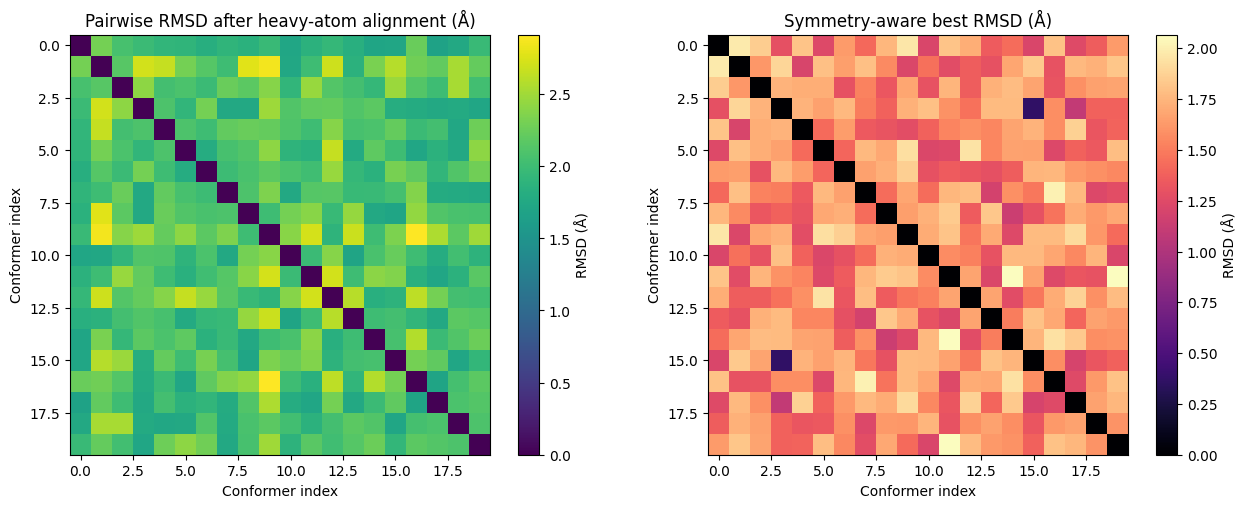

In [49]:
if plt is None:
    print("matplotlib is not installed. Run `pip install matplotlib` for RMSD charts.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    image0 = axes[0].imshow(aligned_rmsd, cmap="viridis")
    axes[0].set_title("Pairwise RMSD after heavy-atom alignment (Å)")
    axes[0].set_xlabel("Conformer index")
    axes[0].set_ylabel("Conformer index")
    fig.colorbar(image0, ax=axes[0], label="RMSD (Å)")

    image1 = axes[1].imshow(best_rmsd, cmap="magma")
    axes[1].set_title("Symmetry-aware best RMSD (Å)")
    axes[1].set_xlabel("Conformer index")
    axes[1].set_ylabel("Conformer index")
    fig.colorbar(image1, ax=axes[1], label="RMSD (Å)")
    plt.tight_layout()
    plt.show()

In [ ]:
if plt is None:
    print("matplotlib is not installed. Run `pip install matplotlib` for RMSD charts.")
elif flat:
    plt.figure(figsize=(8, 4))
    plt.hist(flat, bins=min(20, max(5, len(flat) // 3)), color="#4C78A8", edgecolor="black", alpha=0.75, label="aligned")
    plt.hist(best_flat, bins=min(20, max(5, len(best_flat) // 3)), color="#F58518", edgecolor="black", alpha=0.45, label="best/symmetry-aware")
    plt.title("Pairwise conformer RMSD distribution")
    plt.xlabel("RMSD (Å)")
    plt.ylabel("Conformer pairs")
    plt.legend()
    plt.show()